# Temperature agent — training report

Visualises the walking-skeleton run: the learning curve over iterations and a trained-vs-random comparison. Run `python -m training.train` first to produce the artifacts.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "training" / "config.py").exists():
            return candidate
    raise RuntimeError("could not locate project root (training/config.py not found)")


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from training.config import COMPARE_ENV_CONFIG, CURVE_CSV, LEARNERS, module_dir
from env.training_env import ColdChainTrainingEnv
from training.evaluate import greedy_action_fn, random_action_fn, rollout

AGENT = LEARNERS[0]

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Learning curve

Mean episode return (up = better) and mean crate-temperature deviation from the fruit's ideal midpoint (down = better), per training iteration.

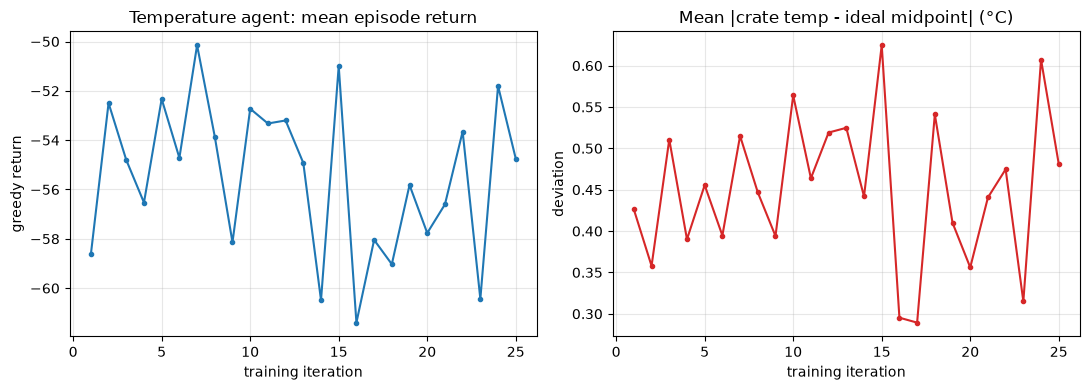

In [2]:
curve = pd.read_csv(CURVE_CSV)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(curve["iteration"], curve["mean_return"], marker="o", ms=3, color="tab:blue")
ax1.set(title="Temperature agent: mean episode return", xlabel="training iteration", ylabel="greedy return")
ax2.plot(curve["iteration"], curve["mean_temp_deviation"], marker="o", ms=3, color="tab:red")
ax2.set(title="Mean |crate temp - ideal midpoint| (°C)", xlabel="training iteration", ylabel="deviation")
fig.tight_layout()
plt.show()

## Trained vs random

Deterministic (greedy) trained policy against a random policy on a held-out set of episodes.

In [ ]:
from ray.rllib.core.rl_module import RLModule

N_EPISODES = 30
action_space = ColdChainTrainingEnv(COMPARE_ENV_CONFIG).action_space(AGENT)
module = RLModule.from_checkpoint(module_dir(AGENT))

trained_return, trained_dev = rollout(
    ColdChainTrainingEnv(COMPARE_ENV_CONFIG), greedy_action_fn(module, action_space, AGENT), N_EPISODES, AGENT
)
random_return, random_dev = rollout(
    ColdChainTrainingEnv(COMPARE_ENV_CONFIG), random_action_fn(action_space, AGENT), N_EPISODES, AGENT
)
margin = (random_dev - trained_dev) / random_dev
print(f"trained deviation: {trained_dev:.3f} °C   random deviation: {random_dev:.3f} °C   (-{margin:.0%})")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["trained", "random"], [trained_dev, random_dev], color=["tab:green", "tab:gray"])
ax.set(title="Mean temperature deviation (lower = better)", ylabel="|temp - ideal| (°C)")
for i, v in enumerate([trained_dev, random_dev]):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")
plt.show()